# Spam Detection — EDA & Chuẩn bị Pipeline
**Thành viên:** C — Machine Learning  
**Tuần 1:** Phân tích EDA, chia dữ liệu, khung pipeline  
**Dataset:** clean_spam_dataset.csv (từ B — 5.169 dòng)

## 1. Import thư viện

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print("Import thành công!")

Import thành công!


## 2. Tải dữ liệu từ B

In [2]:
# Dùng clean_spam_dataset.csv do B xử lý (không dùng data.csv tự tạo)
df = pd.read_csv('clean_spam_dataset.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (5166, 4)


,label,text,clean_text,length
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,102
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni,23
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final...,124
3,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,43
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,59


## 3. Vẽ biểu đồ tỷ lệ spam/ham

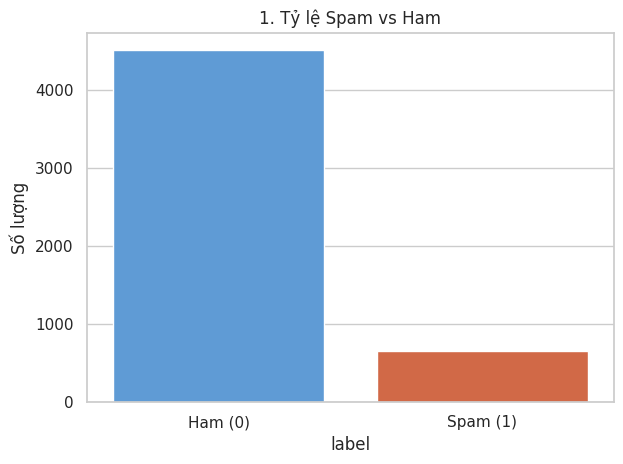

label
0    4513
1     653
Name: count, dtype: int64


In [3]:
# Tỷ lệ spam/ham
sns.countplot(x='label', data=df, palette=['#4C9BE8', '#E85D30'])
plt.xticks([0, 1], ['Ham (0)', 'Spam (1)'])
plt.title('1. Tỷ lệ Spam vs Ham')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.savefig('plot_C_label_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(df['label'].value_counts())

## 4. Vẽ WordCloud tin nhắn Spam

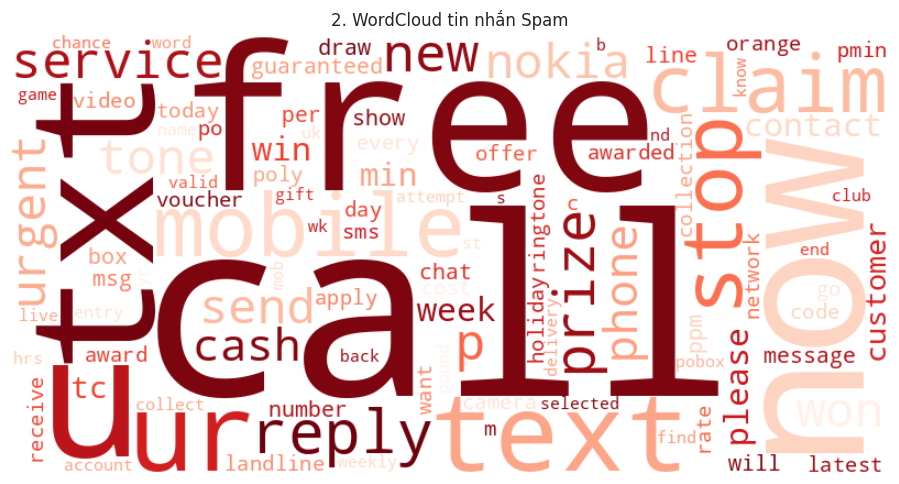

In [4]:
# Dùng cột clean_text (đã xử lý từ B), lọc nhãn spam = 1
spam_words = ' '.join(df[df['label'] == 1]['clean_text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='Reds', max_words=100, collocations=False).generate(spam_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('2. WordCloud tin nhắn Spam')
plt.tight_layout()
plt.savefig('plot_C_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Chia dữ liệu train/test

In [5]:
def split_data(df, test_size=0.2, random_state=42):
    X = df['clean_text']
    y = df['label']
    return train_test_split(X, y, test_size=test_size,
                            random_state=random_state, stratify=y)

X_train, X_test, y_train, y_test = split_data(df)
print(f"Train: {len(X_train)} mẫu  |  Test: {len(X_test)} mẫu")
print(f"Tỷ lệ spam train: {y_train.mean():.3f}  |  Tỷ lệ spam test: {y_test.mean():.3f}")

Train: 4132 mẫu  |  Test: 1034 mẫu
Tỷ lệ spam train: 0.126  |  Tỷ lệ spam test: 0.127


## 6. Khung Pipeline — chuẩn bị cho Tuần 2

In [6]:
# Khung pipeline TF-IDF + Naive Bayes (sẽ mở rộng thêm Logistic Regression ở Tuần 2)
pipeline_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', MultinomialNB())
])
pipeline_model.fit(X_train, y_train)

print("--- KẾT QUẢ ---")
print(f"Đã chia dữ liệu: Train({len(X_train)}), Test({len(X_test)})")
print("Khung Pipeline đã sẵn sàng cho tuần sau!")

--- KẾT QUẢ ---
Đã chia dữ liệu: Train(4132), Test(1034)
Khung Pipeline đã sẵn sàng cho tuần sau!
